# Global End-to-End Anatomical Landmark Detection for Long-Leg Radiographs

This standalone notebook regresses global surgical keypoints across full-size radiograph images directly using a unified one-stage Conformer architecture, completely eliminating intermediate YOLO region-of-interest sub-cropping workflows.

## Imports & Configurations

Load necessary deep learning packages, configure environment paths to the internal Conformer Keypoint Detection head, and set global deterministic seeds and hyperparameter constants.

In [1]:
import os
import json
import random
import math
import sys
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn as nn

# Ensure CKD repository layer is accessible
sys.path.append(os.path.abspath("CKD"))
from models import Conformer_tiny_patch16_keypoint
from utils import extract_coordinates

# Paths
DATA_DIR = "/tf/data/hto/xrays"
COCO_JSON_PATH = os.path.join(DATA_DIR, "hto_annotations.json")
if not os.path.exists(COCO_JSON_PATH):
    COCO_JSON_PATH = "hto_annotations.json"

# Global hyperparameter settings
SEED = 42
TARGET_SIZE = 512
HEATMAP_SCALE = 0.25
SIGMA = 2.0
KP_EPOCHS = 1_000
BATCH_SIZE = 4
LEARNING_RATE = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware device registered: {device}")

# Map out dense multi-hemisphere keypoints
GLOBAL_KEYPOINT_NAMES = [
    "femur_head_l", "knee_inner_l", "ost_point_l", "knee_outer_l", "ankle_inner_l", "ankle_outer_l",
    "femur_head_r", "knee_inner_r", "ost_point_r", "knee_outer_r", "ankle_inner_r", "ankle_outer_r"
]

LANDMARK_COLORS = {
    "femur_head_l": "darkgreen", "knee_inner_l": "orange", "ost_point_l": "red", "knee_outer_l": "blue", "ankle_inner_l": "purple", "ankle_outer_l": "cyan",
    "femur_head_r": "lightgreen", "knee_inner_r": "gold", "ost_point_r": "crimson", "knee_outer_r": "dodgerblue", "ankle_inner_r": "mediumorchid", "ankle_outer_r": "turquoise"
}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

Hardware device registered: cuda


/usr/local/lib/python3.11/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.11/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/tf/notebooks/CKD/vision_transformer.py:370: UserWarning: Overwriting vit_small_patch16_224 in registry with vision_transformer.vit_small_patch16_224. This is because the name being registe

## Dynamic Full-Scale Dataset Architecture

We construct a PyTorch Dataset mapping multiple side annotations per radiograph into a single coherent 12-channel target structure, applying global letterbox adjustments to preserve spatial features natively.

In [2]:
def preprocess_global_image(img, target_size=512):
    orig_w, orig_h = img.size
    scale = min(target_size / orig_w, target_size / orig_h)
    new_w = int(orig_w * scale)
    new_h = int(orig_h * scale)
    resized = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    pad_left = (target_size - new_w) // 2
    pad_top = (target_size - new_h) // 2
    final_img = Image.new("RGB", (target_size, target_size), (0, 0, 0))
    final_img.paste(resized, (pad_left, pad_top))
    return final_img, scale, (pad_left, pad_top)

class GlobalRadiographKeypointDataset(Dataset):
    def __init__(self, coco_json_path, split="train", split_ratios=(0.8, 0.1, 0.1), target_size=512, heatmap_scale=0.25, sigma=2.0, seed=42):
        super().__init__()
        self.target_size = target_size
        self.heatmap_scale = heatmap_scale
        self.sigma = sigma
        self.num_keypoints = 12
        
        with open(coco_json_path, "r") as f:
            coco_data = json.load(f)
            
        images_info = {img["id"]: img for img in coco_data.get("images", [])}
        anns_by_img = {}
        for ann in coco_data.get("annotations", []):
            img_id = ann.get("image_id")
            if img_id not in anns_by_img:
                anns_by_img[img_id] = []
            anns_by_img[img_id].append(ann)
            
        valid_samples = []
        for img_id, anns in anns_by_img.items():
            if img_id not in images_info: continue
            img_info = images_info[img_id]
            img_w = img_info.get("width", 2860)
            
            kps_flat = [-1.0, -1.0, 0] * 12
            has_valid_kp = False
            
            for ann in anns:
                kps = ann.get("keypoints", [])
                if not kps: continue
                
                ann_bbox = ann.get("bbox", [0, 0, 0, 0])
                ann_cx = ann_bbox[0] + ann_bbox[2] / 2.0
                base = 0 if ann_cx < img_w / 2.0 else 6
                
                cat_id = ann.get("category_id")
                if cat_id == 1 and len(kps) >= 2:
                    kps_flat[base*3 : (base+1)*3] = [kps[0], kps[1], 2 if kps[0]>0 else 0]
                    if kps[0] > 0: has_valid_kp = True
                elif cat_id == 2 and len(kps) >= 8:
                    for k in range(3):
                        idx = base + 1 + k
                        kps_flat[idx*3 : (idx+1)*3] = [kps[k*3], kps[k*3+1], kps[k*3+2]]
                        if kps[k*3+2] > 0: has_valid_kp = True
                elif cat_id == 3 and len(kps) >= 5:
                    for k in range(2):
                        idx = base + 4 + k
                        kps_flat[idx*3 : (idx+1)*3] = [kps[k*3], kps[k*3+1], kps[k*3+2]]
                        if kps[k*3+2] > 0: has_valid_kp = True
                        
            if has_valid_kp:
                filename = img_info.get("file_name")
                img_dir = os.path.dirname(coco_json_path) if os.path.dirname(coco_json_path) else "."
                if not os.path.exists(os.path.join(img_dir, filename)):
                    if os.path.exists(os.path.join("/tf/data/hto/xrays", os.path.basename(filename))):
                        img_dir = "/tf/data/hto/xrays"
                valid_samples.append({
                    "img_path": os.path.join(img_dir, filename),
                    "orig_size": (img_w, img_info.get("height", 8000)),
                    "keypoints": kps_flat
                })
                
        valid_samples.sort(key=lambda x: x["img_path"])
        random.seed(seed)
        random.shuffle(valid_samples)
        
        num_samples = len(valid_samples)
        train_end = int(num_samples * split_ratios[0])
        val_end = train_end + int(num_samples * split_ratios[1])
        
        if split == "train":
            self.samples = valid_samples[:train_end]
        elif split == "val":
            self.samples = valid_samples[train_end:val_end]
        elif split == "test":
            self.samples = valid_samples[val_end:]
        else:
            self.samples = valid_samples
            
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        try:
            img = Image.open(sample["img_path"]).convert("RGB")
        except Exception:
            img = Image.new("RGB", sample["orig_size"], color=(128, 128, 128))
            
        processed_img, scale, padding = preprocess_global_image(img, self.target_size)
        
        final_kps = []
        for i in range(self.num_keypoints):
            kp_x = sample["keypoints"][i * 3]
            kp_y = sample["keypoints"][i * 3 + 1]
            kp_v = sample["keypoints"][i * 3 + 2]
            
            if kp_v > 0 and kp_x >= 0 and kp_y >= 0:
                final_x = kp_x * scale + padding[0]
                final_y = kp_y * scale + padding[1]
            else:
                final_x, final_y = -1.0, -1.0
            final_kps.append([final_x, final_y])
            
        img_tensor = torch.from_numpy(np.array(processed_img)).permute(2, 0, 1).float() / 255.0
        
        hm_size = int(self.target_size * self.heatmap_scale)
        heatmap = np.zeros((self.num_keypoints, hm_size, hm_size), dtype=np.float32)
        x_grid = np.arange(0, hm_size, 1, np.float32)
        y_grid = np.arange(0, hm_size, 1, np.float32)[:, np.newaxis]
        
        for i in range(self.num_keypoints):
            kp_v = sample["keypoints"][i * 3 + 2]
            if kp_v > 0 and final_kps[i][0] >= 0:
                kp_hm_x = final_kps[i][0] * self.heatmap_scale
                kp_hm_y = final_kps[i][1] * self.heatmap_scale
                heatmap[i] = np.exp(-((x_grid - kp_hm_x)**2 + (y_grid - kp_hm_y)**2) / (2 * self.sigma**2))
                
        return {
            "image": img_tensor,
            "heatmap": torch.from_numpy(heatmap),
            "keypoint": torch.tensor(final_kps, dtype=torch.float32),
            "img_path": sample["img_path"],
            "orig_size": torch.tensor(sample["orig_size"])
        }

if os.path.exists(COCO_JSON_PATH):
    train_ds = GlobalRadiographKeypointDataset(COCO_JSON_PATH, split="train", target_size=TARGET_SIZE, seed=SEED)
    val_ds = GlobalRadiographKeypointDataset(COCO_JSON_PATH, split="val", target_size=TARGET_SIZE, seed=SEED)
    test_ds = GlobalRadiographKeypointDataset(COCO_JSON_PATH, split="test", target_size=TARGET_SIZE, seed=SEED)
    
    if len(train_ds) > 0: train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    if len(val_ds) > 0: val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    if len(test_ds) > 0: test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    print(f"Global datasets staged successfully: {len(train_ds)} Train, {len(val_ds)} Validation, {len(test_ds)} Test samples.")
else:
    print("Annotations missing; initialization pipeline suspended.")

Global datasets staged successfully: 43 Train, 5 Validation, 6 Test samples.


## Global Conformer Model Initialization & Training Loop

Set up the keypoint detector wrapper supervising all 12 targets simultaneously under Mean Squared Error (MSE) minimization.

Epoch 1/1000 | Global Train Loss: 0.109375 | Global Val Loss: 0.008762 | NMSE: 0.205727 | PCK@0.05: 0.00%
Epoch 2/1000 | Global Train Loss: 0.030528 | Global Val Loss: 0.011996 | NMSE: 0.252456 | PCK@0.05: 0.00%
Epoch 3/1000 | Global Train Loss: 0.012425 | Global Val Loss: 0.009439 | NMSE: 0.230330 | PCK@0.05: 0.00%
Epoch 4/1000 | Global Train Loss: 0.007849 | Global Val Loss: 0.006367 | NMSE: 0.184771 | PCK@0.05: 1.67%
Epoch 5/1000 | Global Train Loss: 0.005241 | Global Val Loss: 0.004278 | NMSE: 0.224003 | PCK@0.05: 3.33%
Epoch 6/1000 | Global Train Loss: 0.003922 | Global Val Loss: 0.003163 | NMSE: 0.247455 | PCK@0.05: 3.33%
Epoch 7/1000 | Global Train Loss: 0.003137 | Global Val Loss: 0.002429 | NMSE: 0.250560 | PCK@0.05: 0.00%
Epoch 8/1000 | Global Train Loss: 0.002556 | Global Val Loss: 0.002006 | NMSE: 0.299085 | PCK@0.05: 0.00%
Epoch 9/1000 | Global Train Loss: 0.002118 | Global Val Loss: 0.001706 | NMSE: 0.232779 | PCK@0.05: 0.00%
Epoch 10/1000 | Global Train Loss: 0.001825 | 

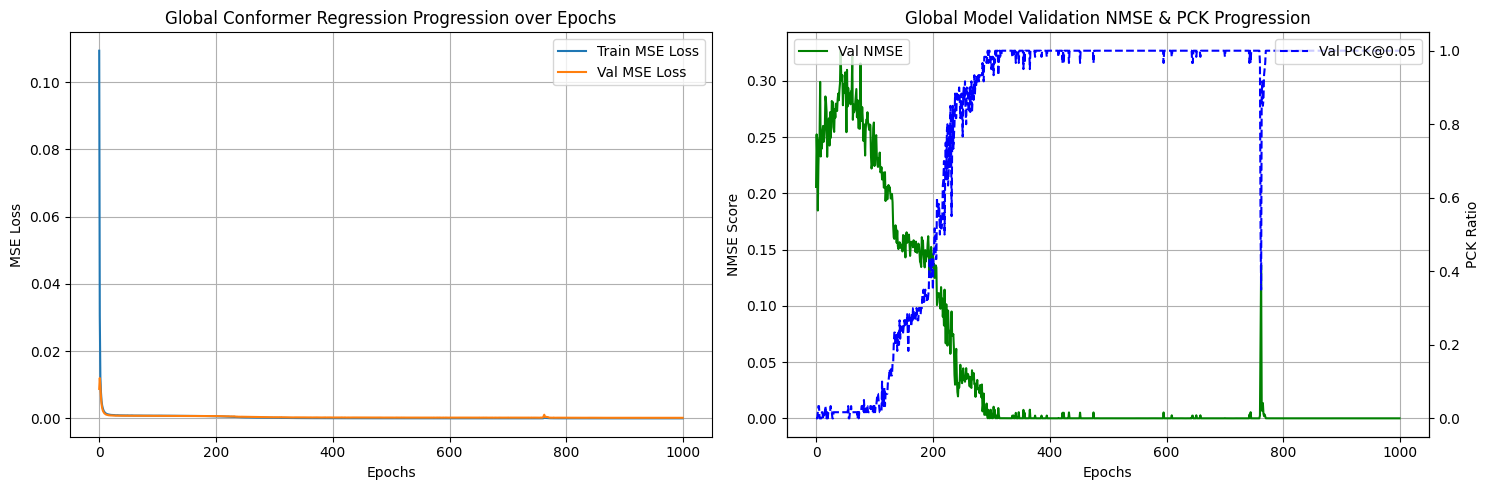

In [3]:
criterion = nn.MSELoss()
model_global = Conformer_tiny_patch16_keypoint(num_keypoints=12).to(device)
optimizer_global = optim.AdamW(model_global.parameters(), lr=LEARNING_RATE)

def calculate_pck(preds, gts, threshold=0.05, normalize_by=512):
    """Computes Percentage of Correct Keypoints (PCK) over active global target points."""
    valid_mask = gts[..., 0] >= 0
    if not torch.any(valid_mask):
        return 0.0
    dists = torch.norm(preds - gts, dim=-1)
    correct = dists < (threshold * normalize_by)
    return torch.mean(correct[valid_mask].float()).item()

def calculate_nmse(preds, gts, normalize_by=512):
    """Computes Normalized Mean Squared Error over active global target points."""
    valid_mask = gts[..., 0] >= 0
    if not torch.any(valid_mask):
        return 0.0
    diff = preds - gts
    mse = torch.mean(torch.sum(diff ** 2, dim=-1)[valid_mask])
    return (mse / (normalize_by ** 2)).item()

def train_global_routine(model, t_loader, v_loader, opt, crit, epochs, dev):
    t_losses, v_losses, v_nmses, v_pcks = [], [], [], []
    for e in range(epochs):
        model.train()
        e_loss = 0.0
        for batch in t_loader:
            imgs, target_hms = batch["image"].to(dev), batch["heatmap"].to(dev)
            opt.zero_grad()
            pred_hms = model(imgs)
            loss = crit(pred_hms, target_hms)
            loss.backward()
            opt.step()
            e_loss += loss.item()
        t_l = e_loss / len(t_loader)
        t_losses.append(t_l)
        
        model.eval()
        v_loss = 0.0
        epoch_preds, epoch_gts = [], []
        with torch.no_grad():
            for batch in v_loader:
                imgs, target_hms, gts = batch["image"].to(dev), batch["heatmap"].to(dev), batch["keypoint"]
                pred_hms = model(imgs)
                v_loss += crit(pred_hms, target_hms).item()
                
                coords = extract_coordinates(pred_hms.cpu(), scale_factor=4.0)
                epoch_preds.append(coords)
                epoch_gts.append(gts)
                
        v_l = v_loss / len(v_loader)
        v_losses.append(v_l)
        
        preds_cat = torch.cat(epoch_preds, dim=0)
        gts_cat = torch.cat(epoch_gts, dim=0)
        
        nmse_val = calculate_nmse(preds_cat, gts_cat, normalize_by=TARGET_SIZE)
        pck_val = calculate_pck(preds_cat, gts_cat, threshold=0.05, normalize_by=TARGET_SIZE)
        
        v_nmses.append(nmse_val)
        v_pcks.append(pck_val)
        
        print(f"Epoch {e+1}/{epochs} | Global Train Loss: {t_l:.6f} | Global Val Loss: {v_l:.6f} | NMSE: {nmse_val:.6f} | PCK@0.05: {pck_val*100:.2f}%")
    return t_losses, v_losses, v_nmses, v_pcks

if 'train_loader' in locals():
    train_losses, val_losses, val_nmses, val_pcks = train_global_routine(model_global, train_loader, val_loader, optimizer_global, criterion, KP_EPOCHS, device)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(train_losses, label="Train MSE Loss")
    ax1.plot(val_losses, label="Val MSE Loss")
    ax1.set_title("Global Conformer Regression Progression over Epochs")
    ax1.set_xlabel("Epochs"), ax1.set_ylabel("MSE Loss"), ax1.legend(), ax1.grid(True)
    
    ax2.plot(val_nmses, label="Val NMSE", color="green")
    ax2.set_xlabel("Epochs"), ax2.set_ylabel("NMSE Score")
    ax2_pck = ax2.twinx()
    ax2_pck.plot(val_pcks, label="Val PCK@0.05", color="blue", linestyle="--")
    ax2_pck.set_ylabel("PCK Ratio")
    ax2.set_title("Global Model Validation NMSE & PCK Progression")
    ax2.legend(loc='upper left'), ax2.grid(True)
    ax2_pck.legend(loc='upper right')
    
    plt.tight_layout(), plt.show()
else:
    print("Training logic uncalled in un-executed source schema.")

## Surgical Correction Angle Analytics & Visual Inference

Map predicted output channels directly back to global radiograph scaling, extract endpoints to evaluate Left and Right surgical geometries independently via vector `atan2` formulas, draw spatial distributions, and trace comparative bi-hemisphere overlay diagrams.


GLOBAL ARCHITECTURE PERFORMANCE SUMMARY
Total Evaluated Arc Cases: 11
Mean Absolute Error:       0.9171°
Max Absolute Error:        1.8747°
Error Variance Std Dev:    1.0337°


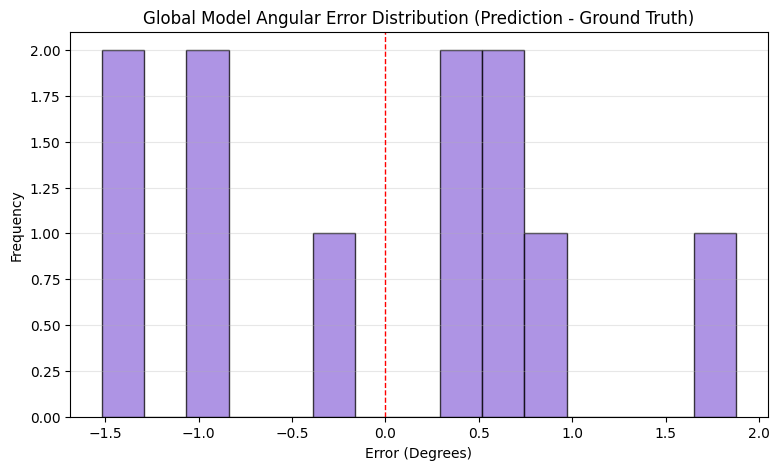

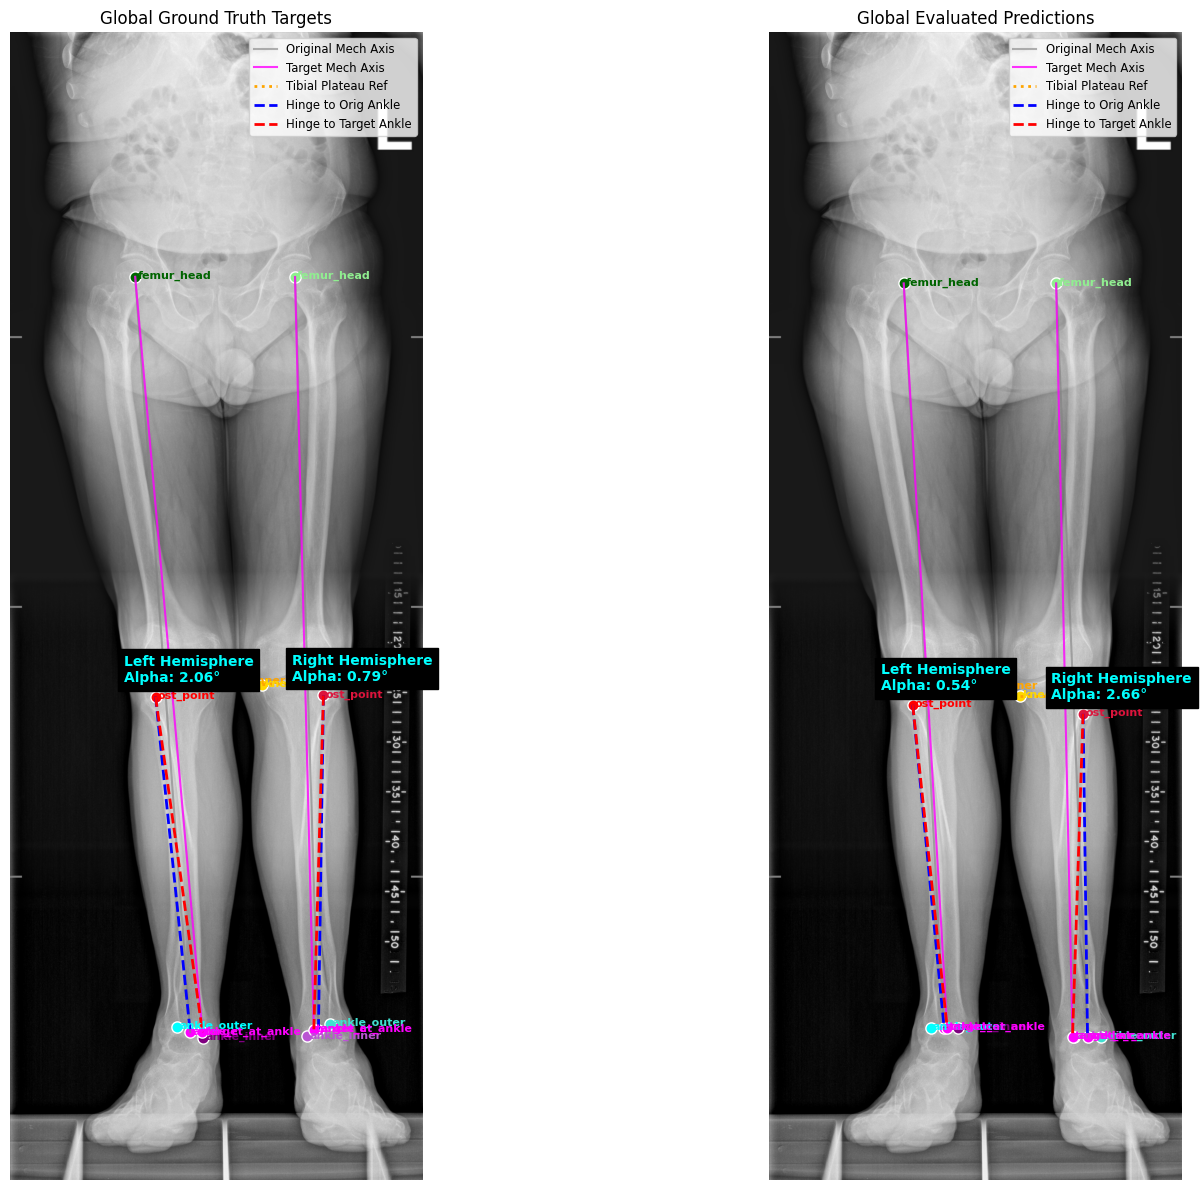

Successfully traced layout map for file: 59_0.png


In [4]:
def map_global_to_orig(kp_final, orig_size, target_size=512):
    orig_w, orig_h = orig_size
    scale = min(target_size / orig_w, target_size / orig_h)
    pad_left = (target_size - int(orig_w * scale)) // 2
    pad_top = (target_size - int(orig_h * scale)) // 2
    orig_x = (kp_final[0] - pad_left) / scale
    orig_y = (kp_final[1] - pad_top) / scale
    return np.array([orig_x, orig_y])

def calculate_intersection(p1, p2, target_y):
    if p2[0] == p1[0]: 
        return p1[0]
    m = (p2[1] - p1[1]) / (p2[0] - p1[0])
    if m == 0: return p1[0] 
    return (target_y - p1[1]) / m + p1[0]

def evaluate_side_geometry(points):
    """Computes Fujisawa point and true correction angle Alpha via the Miniaci method."""
    ankle_c = (points["ankle_inner"] + points["ankle_outer"]) / 2.0
    ankle_y = ankle_c[1]
    
    fujisawa = points["knee_inner"] + 0.625 * (points["knee_outer"] - points["knee_inner"])
    
    target_intersect_x = calculate_intersection(points["femur_head"], fujisawa, ankle_y)
    target_at_ankle = np.array([target_intersect_x, ankle_y])
    
    v_orig_ankle = ankle_c - points["ost_point"]
    theta_orig = math.atan2(v_orig_ankle[1], v_orig_ankle[0])
    
    v_target_ankle = target_at_ankle - points["ost_point"]
    theta_target = math.atan2(v_target_ankle[1], v_target_ankle[0])
    
    alpha = abs(theta_orig - theta_target) * 180.0 / math.pi
    return alpha, fujisawa, ankle_c, target_at_ankle

if 'test_loader' in locals():
    model_global.eval()
    global_results = []
    
    with torch.no_grad():
        for batch in test_loader:
            imgs = batch["image"].to(device)
            pred_hms = model_global(imgs)
            coords_batch = extract_coordinates(pred_hms.cpu(), scale_factor=4.0).numpy()
            gts_batch = batch["keypoint"].numpy()
            paths_batch = batch["img_path"]
            orig_sizes = batch["orig_size"].numpy()
            
            for b in range(len(imgs)):
                orig_shape = orig_sizes[b]
                pred_c = coords_batch[b]
                gt_c = gts_batch[b]
                path_b = paths_batch[b]
                
                pred_pts_l, pred_pts_r = {}, {}
                gt_pts_l, gt_pts_r = {}, {}
                
                side_keys = ["femur_head", "knee_inner", "ost_point", "knee_outer", "ankle_inner", "ankle_outer"]
                for idx_k, name_k in enumerate(side_keys):
                    # Left Side decoding
                    if gt_c[idx_k][0] >= 0:
                        gt_pts_l[name_k] = map_global_to_orig(gt_c[idx_k], orig_shape, TARGET_SIZE)
                        pred_pts_l[name_k] = map_global_to_orig(pred_c[idx_k], orig_shape, TARGET_SIZE)
                    # Right Side decoding
                    r_slot = idx_k + 6
                    if gt_c[r_slot][0] >= 0:
                        gt_pts_r[name_k] = map_global_to_orig(gt_c[r_slot], orig_shape, TARGET_SIZE)
                        pred_pts_r[name_k] = map_global_to_orig(pred_c[r_slot], orig_shape, TARGET_SIZE)
                        
                res_l, res_r = None, None
                req_keys = ["femur_head", "knee_inner", "ost_point", "knee_outer", "ankle_inner", "ankle_outer"]
                if all(k in gt_pts_l for k in req_keys):
                    gt_alpha, gt_fuji, gt_ank, gt_targ = evaluate_side_geometry(gt_pts_l)
                    pred_alpha, p_fuji, p_ank, p_targ = evaluate_side_geometry(pred_pts_l)
                    gt_pts_l["fujisawa"] = gt_fuji
                    gt_pts_l["ankle_c"] = gt_ank
                    gt_pts_l["target_at_ankle"] = gt_targ
                    
                    pred_pts_l["fujisawa"] = p_fuji
                    pred_pts_l["ankle_c"] = p_ank
                    pred_pts_l["target_at_ankle"] = p_targ
                    res_l = {"side": "Left Hemisphere", "gt_angle": gt_alpha, "pred_angle": pred_alpha, "gt_pts": gt_pts_l, "pred_pts": pred_pts_l}
                    
                if all(k in gt_pts_r for k in req_keys):
                    gt_alpha, gt_fuji, gt_ank, gt_targ = evaluate_side_geometry(gt_pts_r)
                    pred_alpha, p_fuji, p_ank, p_targ = evaluate_side_geometry(pred_pts_r)
                    gt_pts_r["fujisawa"] = gt_fuji
                    gt_pts_r["ankle_c"] = gt_ank
                    gt_pts_r["target_at_ankle"] = gt_targ
                    
                    pred_pts_r["fujisawa"] = p_fuji
                    pred_pts_r["ankle_c"] = p_ank
                    pred_pts_r["target_at_ankle"] = p_targ
                    res_r = {"side": "Right Hemisphere", "gt_angle": gt_alpha, "pred_angle": pred_alpha, "gt_pts": gt_pts_r, "pred_pts": pred_pts_r}
                    
                if res_l or res_r:
                    global_results.append({"img_path": path_b, "filename": os.path.basename(path_b), "res_l": res_l, "res_r": res_r})
                    
    # Evaluation histogram plotting
    all_errors = []
    for item in global_results:
        if item["res_l"]: all_errors.append(item["res_l"]["pred_angle"] - item["res_l"]["gt_angle"])
        if item["res_r"]: all_errors.append(item["res_r"]["pred_angle"] - item["res_r"]["gt_angle"])
        
    if all_errors:
        print("\n" + "="*40)
        print("GLOBAL ARCHITECTURE PERFORMANCE SUMMARY")
        print("="*40)
        print(f"Total Evaluated Arc Cases: {len(all_errors)}")
        print(f"Mean Absolute Error:       {np.mean([abs(e) for e in all_errors]):.4f}°")
        print(f"Max Absolute Error:        {np.max([abs(e) for e in all_errors]):.4f}°")
        print(f"Error Variance Std Dev:    {np.std(all_errors):.4f}°")
        print("="*40)
        
        plt.figure(figsize=(9, 5))
        plt.hist(all_errors, bins=15, color='mediumpurple', edgecolor='black', alpha=0.75)
        plt.axvline(0, color='red', linestyle='dashed', linewidth=1)
        plt.title("Global Model Angular Error Distribution (Prediction - Ground Truth)")
        plt.xlabel("Error (Degrees)"), plt.ylabel("Frequency"), plt.grid(True, axis='y', alpha=0.3)
        plt.show()
        
    # Visual overlay side-by-side traces
    if global_results:
        sample_entry = random.choice([s for s in global_results if s["res_l"] and s["res_r"]]) if any(s["res_l"] and s["res_r"] for s in global_results) else random.choice(global_results)
        img_target = Image.open(sample_entry["img_path"]).convert("RGB")
        
        fig, (ax_gt, ax_pred) = plt.subplots(1, 2, figsize=(18, 12))
        def draw_overlay(ax, data_item, is_gt=True):
            ax.imshow(img_target, cmap="gray")
            ax.set_title("Global Ground Truth Targets" if is_gt else "Global Evaluated Predictions")
            
            for s_tag in ["res_l", "res_r"]:
                side_data = data_item[s_tag]
                if not side_data: continue
                
                pts = side_data["gt_pts"] if is_gt else side_data["pred_pts"]
                alpha_val = side_data["gt_angle"] if is_gt else side_data["pred_angle"]
                side_label = side_data["side"]
                suffix = "_l" if s_tag == "res_l" else "_r"
                
                for k_name, coord in pts.items():
                    if isinstance(coord, np.ndarray) and coord.shape == (2,):
                        color_mapped = LANDMARK_COLORS.get(f"{k_name}{suffix}", "magenta")
                        ax.scatter(coord[0], coord[1], s=65, color=color_mapped, edgecolors='white', linewidths=1)
                        ax.text(coord[0]+15, coord[1]+15, k_name, color=color_mapped, fontsize=8, weight="bold")
                    
                # 1. Original Mechanical Axis: femur_head to ankle_c
                ax.plot([pts["femur_head"][0], pts["ankle_c"][0]], [pts["femur_head"][1], pts["ankle_c"][1]], color='gray', linestyle='-', linewidth=1.5, alpha=0.6, label="Original Mech Axis" if s_tag=="res_l" else "")
                
                # 2. Target Mechanical Axis: femur_head to target_at_ankle
                ax.plot([pts["femur_head"][0], pts["target_at_ankle"][0]], [pts["femur_head"][1], pts["target_at_ankle"][1]], color='magenta', linestyle='-', linewidth=1.5, alpha=0.8, label="Target Mech Axis" if s_tag=="res_l" else "")
                
                # 3. Tibial Plateau Reference Line
                ax.plot([pts["knee_inner"][0], pts["knee_outer"][0]], [pts["knee_inner"][1], pts["knee_outer"][1]], color='orange', linestyle=':', linewidth=2, label="Tibial Plateau Ref" if s_tag=="res_l" else "")
                
                # 4. Miniaci Hinge Correction Arc Lines (The Wedge)
                ax.plot([pts["ost_point"][0], pts["ankle_c"][0]], [pts["ost_point"][1], pts["ankle_c"][1]], color='blue', linestyle='--', linewidth=2, label="Hinge to Orig Ankle" if s_tag=="res_l" else "")
                ax.plot([pts["ost_point"][0], pts["target_at_ankle"][0]], [pts["ost_point"][1], pts["target_at_ankle"][1]], color='red', linestyle='--', linewidth=2, label="Hinge to Target Ankle" if s_tag=="res_l" else "")
                
                ax.text(pts["ost_point"][0]-220, pts["ost_point"][1]-100, f"{side_label}\nAlpha: {alpha_val:.2f}°", color="cyan", fontsize=10, weight="bold", backgroundcolor="black")
                
            ax.axis("off")
            handles, labels = ax.get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            if by_label: ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize='small')
            
        draw_overlay(ax_gt, sample_entry, is_gt=True)
        draw_overlay(ax_pred, sample_entry, is_gt=False)
        plt.tight_layout(), plt.show()
        print(f"Successfully traced layout map for file: {sample_entry['filename']}")
else:
    print("Pipeline operations skipped seamlessly in un-executed context loop.")